In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("loan_risk_prediction_dataset.csv")
df


,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0
...,...,...,...,...,...,...,...,...,...,...
4995,24,36780.0,23383.0,NaN,23,Male,Masters,Houston,Salaried,0
4996,66,99146.0,9760.0,306.0,14,Male,PhD,New York,Unemployed,0
4997,26,58100.0,18230.0,311.0,10,Female,High School,San Francisco,Self-Employed,0
4998,53,58513.0,12373.0,813.0,23,Male,PhD,Houston,Salaried,1


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        4802 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB


In [3]:
df.isnull().sum()

Age                  0
Income             196
LoanAmount           0
CreditScore        194
YearsExperience      0
Gender               0
Education          198
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64

In [4]:
df.describe()

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
count,5000.000000,4804.000000,5000.000000,4806.000000,5000.000000,5000.000000
mean,43.584600,49738.123022,19870.768600,575.494590,19.599000,0.230200
std,14.919094,15101.361851,8046.542413,160.550839,11.516837,0.421003
min,18.000000,-3731.000000,-10059.000000,300.000000,0.000000,0.000000
25%,31.000000,39608.500000,14455.250000,433.000000,10.000000,0.000000
50%,43.000000,49488.000000,19842.500000,579.000000,20.000000,0.000000
75%,56.000000,59917.000000,25326.750000,712.000000,29.000000,0.000000
max,69.000000,99146.000000,48353.000000,849.000000,39.000000,1.000000


In [5]:
df.shape

(5000, 10)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.drop('Gender', axis=1, inplace=True)

In [8]:
df['Income'] = df['Income'].fillna(df['Income'].median())
df['CreditScore'] = df['CreditScore'].fillna(df['CreditScore'].median())


In [9]:
df.isnull().sum()

Age                  0
Income               0
LoanAmount           0
CreditScore          0
YearsExperience      0
Education          198
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64

In [10]:
df

,Age,Income,LoanAmount,CreditScore,YearsExperience,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,High School,Chicago,Unemployed,0
...,...,...,...,...,...,...,...,...,...
4995,24,36780.0,23383.0,579.0,23,Masters,Houston,Salaried,0
4996,66,99146.0,9760.0,306.0,14,PhD,New York,Unemployed,0
4997,26,58100.0,18230.0,311.0,10,High School,San Francisco,Self-Employed,0
4998,53,58513.0,12373.0,813.0,23,PhD,Houston,Salaried,1


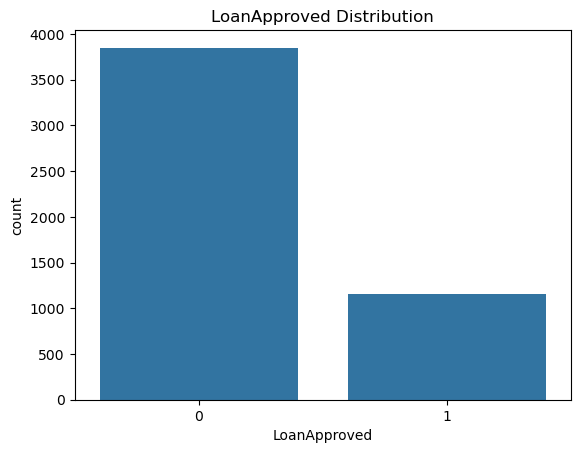

In [11]:
sns.countplot(x='LoanApproved', data=df)
plt.title("LoanApproved Distribution")
plt.show()

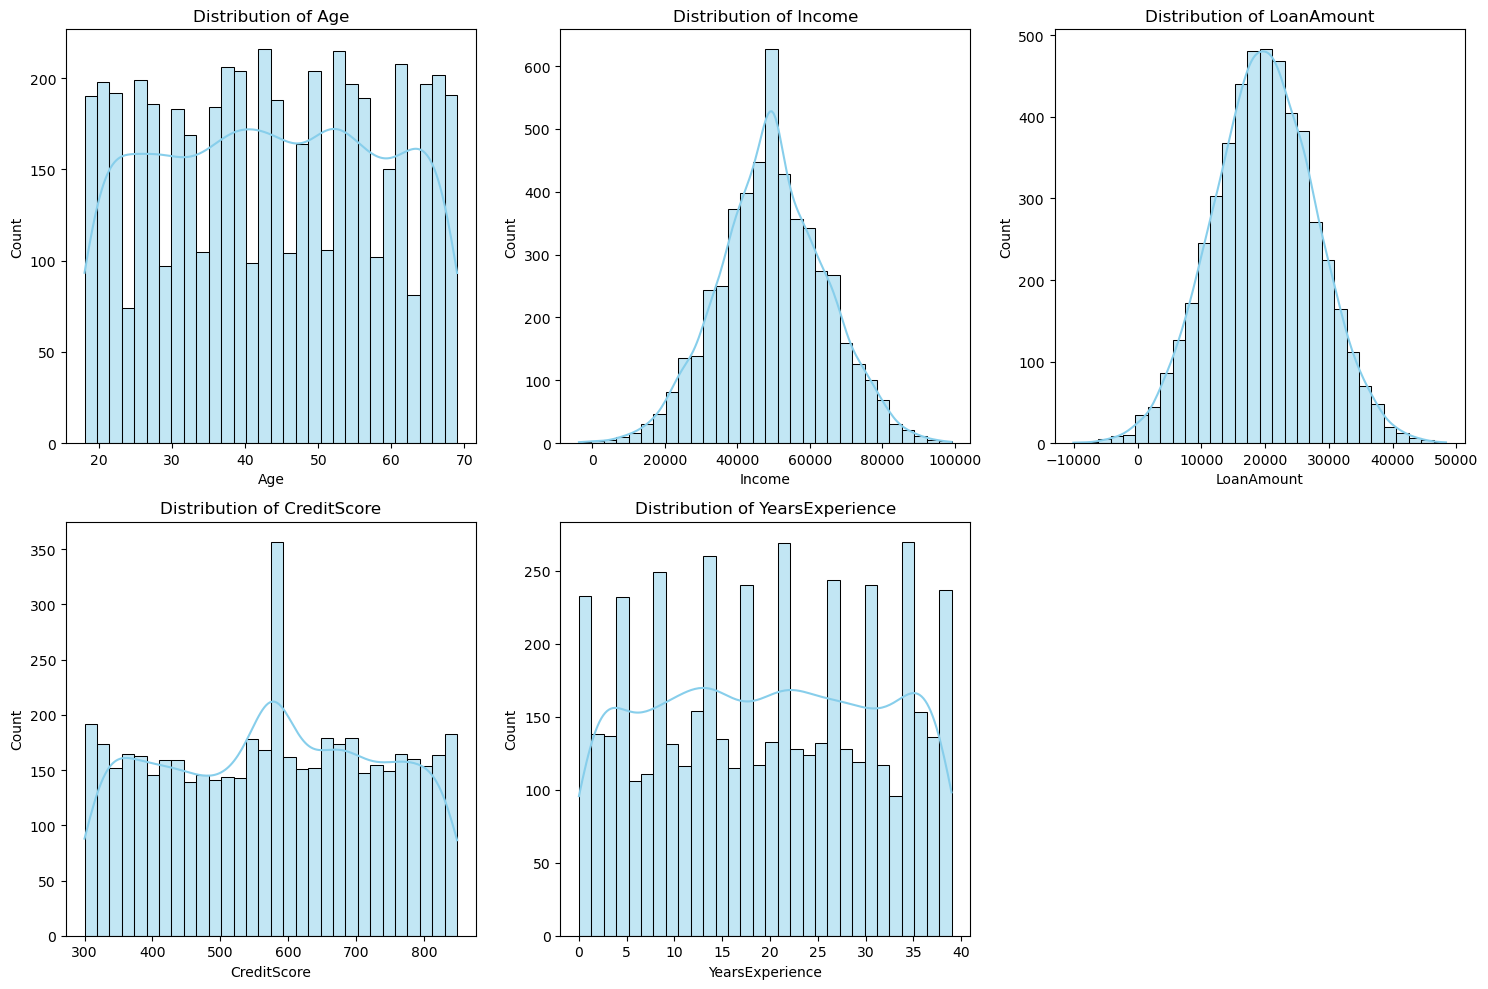

In [12]:
num_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
plt.tight_layout()
plt.show()

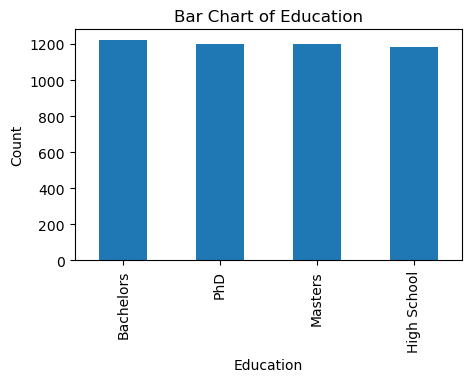

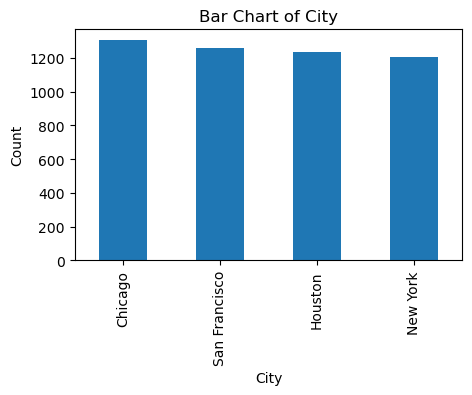

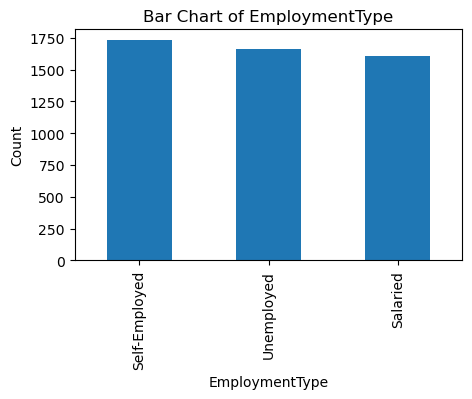

In [13]:
cat_cols = ['Education','City','EmploymentType',]
for col in cat_cols:
    plt.figure(figsize=(5,3))
    df[col].value_counts().plot(kind='bar')
    plt.title(f"Bar Chart of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


In [14]:
education_map = {
    'High School': 0,
    'Bachelor': 1,
    'Master': 2,
    'PhD': 3
}

df['Education'] = df['Education'].map(education_map)

In [15]:
df['Education'] = df['Education'].fillna(df['Education'].mode()[0])

In [16]:
df.isnull().sum()

Age                0
Income             0
LoanAmount         0
CreditScore        0
YearsExperience    0
Education          0
City               0
EmploymentType     0
LoanApproved       0
dtype: int64

In [17]:
df = pd.get_dummies(df, columns=['City'], drop_first=True)

In [18]:
df = pd.get_dummies(df, columns=['EmploymentType'], drop_first=True)

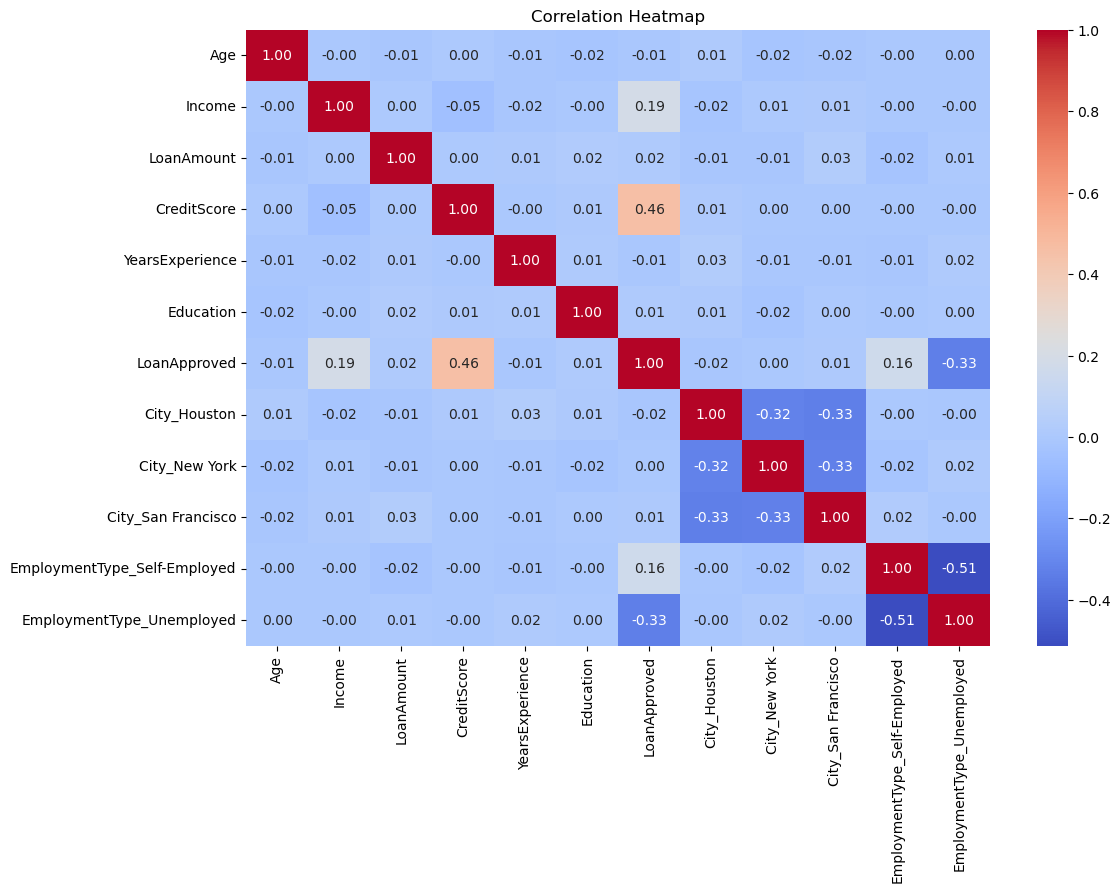

In [19]:
corr = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [20]:
target_corr = corr['LoanApproved'].drop('LoanApproved').sort_values(ascending=False)

decision_df = pd.DataFrame({
    'Feature': target_corr.index,
    'Correlation': target_corr.values,
    'Decision': ['Strong' if abs(x) > 0.6 else 'Medium' if abs(x) > 0.4 else 'Weak' for x in target_corr]
})

In [21]:
def style_decision_table(df):
    return df.style.set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#1a5b7a'), ('color', 'white'), 
                                    ('font-family', 'Arial'), ('text-align', 'center'), ('padding', '10px')]},
        {'selector': 'td', 'props': [('background-color', '#d9effc'), ('color', 'black'), 
                                    ('border', '1px solid #7ebed9'), ('padding', '8px')]}
    ]).hide(axis='index').background_gradient(subset=['Correlation'], cmap='Blues')

style_decision_table(decision_df)

Feature,Correlation,Decision
CreditScore,0.460991,Medium
Income,0.186923,Weak
EmploymentType_Self-Employed,0.164550,Weak
LoanAmount,0.018302,Weak
Education,0.013169,Weak
City_San Francisco,0.011651,Weak
City_New York,0.000165,Weak
YearsExperience,-0.006372,Weak
Age,-0.008754,Weak
City_Houston,-0.016104,Weak


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['LoanApproved'])
y = df['LoanApproved']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("X_train shape:", X_train_res.shape)
print("y_train shape:", y_train_res.shape)

X_train shape: (6158, 11)
y_train shape: (6158,)


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_res, y_train_res)
y_pred = lr.predict(X_test_scaled)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Logistic Regression
Accuracy: 0.863
              precision    recall  f1-score   support

           0       0.96      0.86      0.91       770
           1       0.65      0.88      0.75       230

    accuracy                           0.86      1000
   macro avg       0.80      0.87      0.83      1000
weighted avg       0.89      0.86      0.87      1000



In [25]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
svm = SVC(kernel='rbf', C=1.0, gamma='scale')
svm.fit(X_train_res, y_train_res)

y_pred_svm = svm.predict(X_test_scaled)

print("SVM Results")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Results
Accuracy: 0.898
              precision    recall  f1-score   support

           0       0.96      0.91      0.93       770
           1       0.74      0.87      0.80       230

    accuracy                           0.90      1000
   macro avg       0.85      0.89      0.86      1000
weighted avg       0.91      0.90      0.90      1000



In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test_scaled)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.962
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       770
           1       0.94      0.89      0.91       230

    accuracy                           0.96      1000
   macro avg       0.96      0.94      0.95      1000
weighted avg       0.96      0.96      0.96      1000



In [27]:
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train
xgb.fit(X_train_res, y_train_res)

# Predict
y_pred_xgb = xgb.predict(X_test_scaled)

# Evaluation
print("XGBoost Results")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Results
Accuracy: 0.956
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       770
           1       0.93      0.88      0.90       230

    accuracy                           0.96      1000
   macro avg       0.95      0.93      0.94      1000
weighted avg       0.96      0.96      0.96      1000



C:\Users\oraby\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:57:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [28]:
from sklearn.metrics import accuracy_score, f1_score

results = {}

# Logistic Regression
y_pred_lr = lr.predict(X_test_scaled)
results["Logistic Regression"] = {
    "accuracy": accuracy_score(y_test, y_pred_lr),
    "f1": f1_score(y_test, y_pred_lr)
}

# SVM
y_pred_svm = svm.predict(X_test_scaled)
results["SVM"] = {
    "accuracy": accuracy_score(y_test, y_pred_svm),
    "f1": f1_score(y_test, y_pred_svm)
}

# Random Forest
y_pred_rf = rf.predict(X_test_scaled)
results["Random Forest"] = {
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "f1": f1_score(y_test, y_pred_rf)
}

# XGBoost
y_pred_xgb = xgb.predict(X_test_scaled)
results["XGBoost"] = {
    "accuracy": accuracy_score(y_test, y_pred_xgb),
    "f1": f1_score(y_test, y_pred_xgb)
}

for model, scores in results.items():
    print(f"{model}: Accuracy={scores['accuracy']:.4f}, F1={scores['f1']:.4f}")


best_model = max(results, key=lambda x: results[x]["f1"])

print("\n Best Model:", best_model)
print("Scores:", results[best_model])

Logistic Regression: Accuracy=0.8630, F1=0.7477
SVM: Accuracy=0.8980, F1=0.7960
Random Forest: Accuracy=0.9620, F1=0.9148
XGBoost: Accuracy=0.9560, F1=0.9018

 Best Model: Random Forest
Scores: {'accuracy': 0.962, 'f1': 0.9147982062780269}


In [29]:
import joblib

joblib.dump(rf, "ٌrf_model.pkl")   
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns, "columns.pkl")

['columns.pkl']